# 11 · Rate optimisation v2 — LP bound, exact MILP, and a robust counterpart

### Is the LP relaxation fine, or should it be done separately from the MILP?
Keep **both, in the same notebook, with different jobs**:

* The problem is a *multiple-choice knapsack*: 7,300 "pick exactly one of 41 rates" rows plus only 3 portfolio constraints (retention, MLR ceiling, MLR floor). A basic optimal LP solution can split **at most as many accounts as there are coupling constraints** across two rates — here ≤3 of 7,300 (≤6 with the robust constraints). So the LP optimum is almost integral and its objective is a near-tight **upper bound**.
* The **MILP** then gives the actual integer decision and a **proven** gap against that bound. In v1 the MILP was never executed (`RUN_FULL_MILP = False` in notebooks 06 and 07), so the "MILP" results were the greedy heuristic with no optimality certificate. Calling HiGHS through `highspy` (instead of `scipy.optimize.milp` with a 30 s limit) solves the full 299,300-binary model to optimality in about 1–2 minutes on one core.
* Lagrangian decomposition (notebook 05) is the same bound seen from the dual side; it is not needed as a separate production step.

### Why the v1 answer broke under stress
The v1 optimiser was told only to *meet* the limits in the expected case, so it drove retention to **exactly 80.000%** and stopped. Any adverse movement at all then fails. The fix is to write robustness **into the constraints** — the limits must also hold in plausible adverse scenarios — and to measure what that insurance costs.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' if (ROOT / 'data').exists() else ROOT   # raw input files
sys.path.insert(0, str(ROOT / 'notebooks'))
from trackA_v2_utils import RATES, solve_rate_mip, portfolio_metrics, RenewalStress, grid_economics

IN = ROOT / 'outputs' / 'v2' / '01_renewal_model'
OUT = ROOT / 'outputs' / 'v2' / '02_optimisation'; (OUT / 'plots').mkdir(parents=True, exist_ok=True)
G = np.load(IN / 'grid_2026_v2.npz', allow_pickle=True)
snap = pd.read_csv(IN / 'account_snapshot_2026_v2.csv')
assert (snap['account_id'].to_numpy() == G['account_id']).all()
P, Zg, beta = G['P'], G['Zg'], G['beta']
prem0, claims0 = snap['annual_premium_2025'].to_numpy(), snap['paid_claims_2025'].to_numpy()
N, K = P.shape
stress = RenewalStress(Zg, beta, G['rate_idx'])
assert np.allclose(stress.P, P, atol=1e-5)
print(N, 'accounts x', K, 'actions; FY2025 claims carried forward with no trend (README primary case)')

7300 accounts x 41 actions; FY2025 claims carried forward with no trend (README primary case)


## 1 · Benchmarks: do nothing, and a broad increase

In [2]:
rows = []
for r in [0, 5, 10, 15, 20, 25]:
    m = portfolio_metrics(np.full(N, int(np.where(RATES == r)[0][0])), P, prem0, claims0)
    rows.append({'strategy': f'uniform {r:+d}%', **m})
bench = pd.DataFrame(rows); bench.to_csv(OUT / 'benchmark_uniform_rates.csv', index=False)
display(bench[['strategy', 'account_retention', 'case_mlr', 'expected_contribution']].round(4))
# A flat book-wide increase cannot reach the corridor without breaking 80% retention:
# healthy accounts lapse, high-risk accounts stay, MLR barely moves.

,strategy,account_retention,case_mlr,expected_contribution
0,uniform +0%,0.9193,0.9182,1.130612e+09
1,uniform +5%,0.8814,0.8896,1.539220e+09
2,uniform +10%,0.8294,0.8702,1.787176e+09
3,uniform +15%,0.7616,0.8612,1.839349e+09
4,uniform +20%,0.6785,0.8639,1.683171e+09
5,uniform +25%,0.5839,0.8794,1.343756e+09


## 2 · Nominal problem (the brief's limits only): LP bound, then exact MILP

In [3]:
x_lp, _, lp_info = solve_rate_mip(P, prem0, claims0, integer=False)
x_nom, choice_nom, nom_info = solve_rate_mip(P, prem0, claims0, integer=True)
nom = portfolio_metrics(choice_nom, P, prem0, claims0)
solver = pd.DataFrame([{'run': 'nominal LP relaxation', **{k: v for k, v in lp_info.items() if k != 'constraint_names'}},
                       {'run': 'nominal MILP', **{k: v for k, v in nom_info.items() if k != 'constraint_names'}}])
display(solver.round(6)); display(pd.Series(nom).round(4))
print(f"LP bound - MILP objective = ${lp_info['objective'] - nom_info['objective']:,.0f}  (gap {nom_info['mip_gap']:.2e})")
# On the corrected curve the nominal optimum clears the limits with very little headroom:
# retention ~80.7% and MLR ~80.9%. That thin headroom is why a fixed-rate stress fails.

,run,solver_status,runtime_seconds,objective,fractional_accounts,n_coupling_constraints,best_bound,mip_gap
0,nominal LP relaxation,Optimal,51.867844,2.636389e+09,0,3,NaN,NaN
1,nominal MILP,Optimal,98.574141,2.636389e+09,0,3,2.636389e+09,0.0


account_retention             8.071000e-01
premium_weighted_retention    8.100000e-01
expected_premium              1.378126e+10
expected_claims               1.114487e+10
case_mlr                      8.087000e-01
expected_contribution         2.636389e+09
avg_rate_premium_weighted     1.357360e+01
accounts_at_cap               1.825000e+03
accounts_with_cut             0.000000e+00
dtype: float64

LP bound - MILP objective = $0  (gap 0.00e+00)


## 3 · Robust counterpart

The brief's three limits are kept exactly, **and** the same limits are imposed under three adverse scenarios, each added as extra linear rows (the model stays a MILP):

| Robust scenario | What it represents | Calibration |
|---|---|---|
| **Lapse shock** — logit(p) − δ, δ = 0.19 | market-wide loss of renewals; applied in logit space it hits price-sensitive, healthier accounts hardest (adverse selection) | δ = 0.19 removes ≈3 pts of retention — the "moderate adverse" stress, ≈5× the Monte-Carlo s.d. of retention |
| **Price-sensitive market** — rate terms × 1.25 | competitors hold price; the rate slope is steeper than history | ≈2.3 standard errors on the rate coefficient (s.e. ≈ 11%) |
| **Claims +4%** | adverse FY2026 experience with no pricing response | the largest shock a 5-pt corridor can absorb while keeping the 80% floor at base |

Retention ≥ 80% must hold under the first two; MLR ≤ 85% must hold under all three.

In [4]:
DELTA, ELASTIC, CLAIMS_UP = 0.19, 1.25, 1.04
def robust_set(level=1.0):
    return [dict(name='lapse_shock', P=stress.shift(level * DELTA), claim_mult=1.0, R=0.80, U=0.85),
            dict(name='price_sensitive', P=stress.elastic(1 + level * (ELASTIC - 1)), claim_mult=1.0, R=0.80, U=0.85),
            dict(name='claims_up', P=P, claim_mult=1 + level * (CLAIMS_UP - 1), R=None, U=0.85)]
x_rob, choice_rob, rob_info = solve_rate_mip(P, prem0, claims0, robust_scenarios=robust_set(1.0), integer=True)
rob = portfolio_metrics(choice_rob, P, prem0, claims0)
display(pd.DataFrame([{'run': 'robust MILP', **{k: v for k, v in rob_info.items() if k != 'constraint_names'}}]).round(6))
check = pd.DataFrame({'nominal': {**nom}, 'robust': {**rob}})
for s in robust_set(1.0):
    for name, ch in [('nominal', choice_nom), ('robust', choice_rob)]:
        m = portfolio_metrics(ch, s['P'], prem0, claims0, s['claim_mult'])
        check.loc[f"{s['name']}: retention", name] = m['account_retention']; check.loc[f"{s['name']}: MLR", name] = m['case_mlr']
display(check.round(4))
print(f"Cost of robustness: ${(nom['expected_contribution'] - rob['expected_contribution'])/1e6:,.1f}m "
      f"({(nom['expected_contribution'] - rob['expected_contribution'])/nom['expected_contribution']:.2%} of nominal contribution)")

,run,solver_status,runtime_seconds,objective,fractional_accounts,n_coupling_constraints,best_bound,mip_gap
0,robust MILP,Optimal,140.13516,2.612325e+09,0,8,2.612325e+09,0.0


,nominal,robust
account_retention,8.071000e-01,8.375000e-01
premium_weighted_retention,8.100000e-01,8.292000e-01
expected_premium,1.378126e+10,1.393624e+10
expected_claims,1.114487e+10,1.132392e+10
case_mlr,8.087000e-01,8.126000e-01
expected_contribution,2.636389e+09,2.612325e+09
avg_rate_premium_weighted,1.357360e+01,1.218540e+01
accounts_at_cap,1.825000e+03,1.504000e+03
accounts_with_cut,0.000000e+00,0.000000e+00
lapse_shock: retention,7.770000e-01,8.109000e-01


Cost of robustness: $24.1m (0.91% of nominal contribution)


## 4 · Price of robustness (one dial scales all three scenarios)
Level 0 = nominal, 1 = recommended. Intermediate/extreme levels are solved as LPs — the bound is tight to ≤6 fractional accounts, which is plenty for a frontier.

,robustness_level,method,expected_contribution,account_retention,case_mlr,avg_rate_premium_weighted
0,0.0,MILP,2.636389e+09,0.8071,0.8087,13.5736
2,0.5,LP (1 fractional),2.631764e+09,0.8212,0.8100,12.9809
1,1.0,MILP,2.612325e+09,0.8375,0.8126,12.1854
3,1.5,LP (Infeasible),NaN,NaN,NaN,NaN
4,2.0,LP (Infeasible),NaN,NaN,NaN,NaN


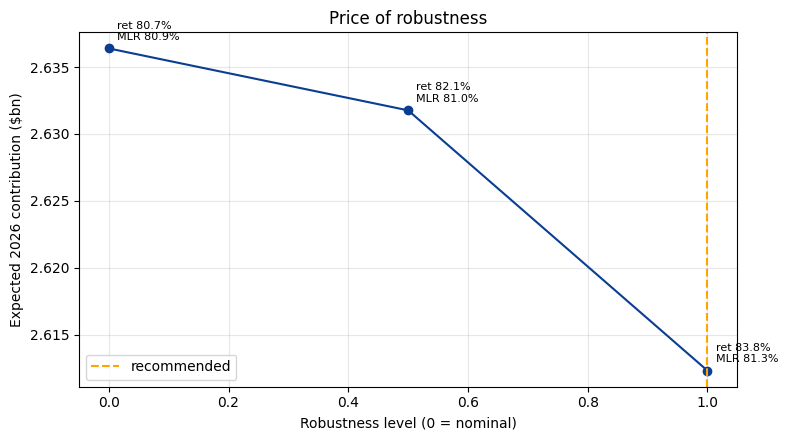

In [5]:
front = [{'robustness_level': 0.0, 'method': 'MILP', **nom}, {'robustness_level': 1.0, 'method': 'MILP', **rob}]
for level in [0.5, 1.5, 2.0]:
    x, _, info = solve_rate_mip(P, prem0, claims0, robust_scenarios=robust_set(level), integer=False)
    if info['solver_status'] != 'Optimal':
        front.append({'robustness_level': level, 'method': f"LP ({info['solver_status']})"}); continue
    front.append({'robustness_level': level, 'method': f"LP ({info['fractional_accounts']} fractional)", **portfolio_metrics(x.argmax(1), P, prem0, claims0)})
front = pd.DataFrame(front).sort_values('robustness_level'); front.to_csv(OUT / 'price_of_robustness_frontier.csv', index=False)
display(front[['robustness_level', 'method', 'expected_contribution', 'account_retention', 'case_mlr', 'avg_rate_premium_weighted']].round(4))
ok = front.dropna(subset=['expected_contribution'])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ok['robustness_level'], ok['expected_contribution'] / 1e9, 'o-', color='#0b3d91')
for _, r in ok.iterrows():
    ax.annotate(f"ret {r.account_retention:.1%}\nMLR {r.case_mlr:.1%}", (r.robustness_level, r.expected_contribution / 1e9), textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.axvline(1, color='orange', ls='--', label='recommended'); ax.set_xlabel('Robustness level (0 = nominal)'); ax.set_ylabel('Expected 2026 contribution ($bn)')
ax.set_title('Price of robustness'); ax.grid(alpha=.3); ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'plots' / '01_price_of_robustness.png', dpi=170); plt.show()

## 5 · Client guardrails from notebook 07, added to the robust MILP

| Guardrail (notebook 07) | Type | Kept in final? |
|---|---|---|
| Premium-weighted retention ≥ 80% (FY2025 premium weights) | portfolio row | ✓ |
| Retained average risk score within ±15% of today's | 2 portfolio rows | ✓ |
| Top-50 accounts by premium: rate ≤ +15% (broker / relationship risk) | per-account bound | ✓ |
| +25% soft penalty = 0.5% of FY2025 premium (discourages cap clustering) | objective | ✓ |
| Accounts with FY2025 MLR > 110% restricted to +15…+20% | per-account bound | ✗ tested, dropped — see below |

Three runs are solved so the decision to drop the band rule is evidenced, not asserted: (a) robust + **all** guardrails, (b) nominal limits + all guardrails, (c) robust + guardrails without the band rule (**final**).

In [6]:
risk = snap['risk_score_2025'].to_numpy(); avg_risk = risk.mean(); mlr0 = claims0 / prem0
guard_rows = [('premium_weighted_retention', prem0[:, None] * P, 0.80 * prem0.sum(), np.inf),
              ('risk_mix_upper', P * (risk - 1.15 * avg_risk)[:, None], -np.inf, 0.0),
              ('risk_mix_lower', P * (0.85 * avg_risk - risk)[:, None], -np.inf, 0.0)]
top50 = np.zeros(N, bool); top50[np.argsort(-prem0)[:50]] = True
allow_top50 = ~(top50[:, None] & (RATES[None, :] > 15))
allow_band = ~((mlr0 > 1.10)[:, None] & ~((RATES >= 15) & (RATES <= 20))[None, :])
penalty25 = 0.005 * prem0[:, None] * (RATES[None, :] == 25)
runs = {}
for name, rob_set, allowed in [('robust + all guardrails', robust_set(1.0), allow_top50 & allow_band),
                               ('nominal + all guardrails', (), allow_top50 & allow_band),
                               ('robust + guardrails, no MLR>110% band rule (FINAL)', robust_set(1.0), allow_top50)]:
    x, ch, info = solve_rate_mip(P, prem0, claims0, robust_scenarios=rob_set, extra_rows=guard_rows, allowed=allowed, objective_penalty=penalty25)
    runs[name] = (ch, info); print(name, '->', info['solver_status'], f"{info['runtime_seconds']:.0f}s", f"gap={info.get('mip_gap')}")
choice_fin, fin_info = runs['robust + guardrails, no MLR>110% band rule (FINAL)']
assert fin_info['solver_status'] == 'Optimal'
fin = portfolio_metrics(choice_fin, P, prem0, claims0)
gr = []
for name, (ch, info) in runs.items():
    row = {'run': name, 'solver_status': info['solver_status'], 'mip_gap': info.get('mip_gap')}
    if info['solver_status'] == 'Optimal': row.update(portfolio_metrics(ch, P, prem0, claims0))
    gr.append(row)
gr = pd.DataFrame(gr); gr.to_csv(OUT / 'guardrail_runs.csv', index=False)
display(gr[['run', 'solver_status', 'expected_contribution', 'account_retention', 'premium_weighted_retention', 'case_mlr', 'accounts_at_cap']].round(4))

robust + all guardrails -> Infeasible 160s gap=inf


nominal + all guardrails -> Optimal 141s gap=0.0


robust + guardrails, no MLR>110% band rule (FINAL) -> Optimal 203s gap=6.867994423645933e-08


,run,solver_status,expected_contribution,account_retention,premium_weighted_retention,case_mlr,accounts_at_cap
0,robust + all guardrails,Infeasible,NaN,NaN,NaN,NaN,NaN
1,nominal + all guardrails,Optimal,2.405436e+09,0.8174,0.8212,0.8261,13.0
2,"robust + guardrails, no MLR>110% band rule (FI...",Optimal,2.585942e+09,0.8375,0.8304,0.8145,1211.0


In [7]:
i = np.arange(N); pf = P[i, choice_fin]; rf = RATES[choice_fin]
compliance = pd.DataFrame([
    ('one rate per account, 7,300 accounts', len(choice_fin) == N),
    ('all rates within -15%..+25%', bool(((rf >= -15) & (rf <= 25)).all())),
    ('account retention >= 80%', fin['account_retention'] >= .80),
    ('case MLR within 80-85%', .80 <= fin['case_mlr'] <= .85),
    ('premium-weighted retention >= 80%', fin['premium_weighted_retention'] >= .80),
    ('retained risk mix within +-15%', abs(np.average(risk, weights=pf) / avg_risk - 1) <= .15),
    ('top-50 accounts <= +15%', bool((rf[top50] <= 15).all())),
] + [(f"robust: {s['name']} retention >= 80%", portfolio_metrics(choice_fin, s['P'], prem0, claims0, s['claim_mult'])['account_retention'] >= .80) for s in robust_set(1.0) if s['R']]
  + [(f"robust: {s['name']} MLR <= 85%", portfolio_metrics(choice_fin, s['P'], prem0, claims0, s['claim_mult'])['case_mlr'] <= .85) for s in robust_set(1.0)],
  columns=['check', 'pass'])
compliance['value'] = [N, f'{rf.min()}..{rf.max()}', fin['account_retention'], fin['case_mlr'], fin['premium_weighted_retention'],
                       np.average(risk, weights=pf) / avg_risk - 1, int(rf[top50].max())] + [None] * (len(compliance) - 7)
compliance.to_csv(OUT / 'final_constraint_compliance.csv', index=False); display(compliance)
assert compliance['pass'].all()
print(f"Guardrail cost vs robust-only: ${(rob['expected_contribution'] - fin['expected_contribution'])/1e6:,.1f}m")

,check,pass,value
0,"one rate per account, 7,300 accounts",True,7300
1,all rates within -15%..+25%,True,0..25
2,account retention >= 80%,True,0.837467
3,case MLR within 80-85%,True,0.814503
4,premium-weighted retention >= 80%,True,0.830382
5,retained risk mix within +-15%,True,0.022131
6,top-50 accounts <= +15%,True,15
7,robust: lapse_shock retention >= 80%,True,None
8,robust: price_sensitive retention >= 80%,True,None
9,robust: lapse_shock MLR <= 85%,True,None


Guardrail cost vs robust-only: $26.4m


## 6 · Recommended rates (FINAL = robust + guardrails): outputs, segment view, submission file

In [8]:
i = np.arange(N)
def account_table(choice):
    r = RATES[choice]; p = P[i, choice]
    t = snap[['account_id', 'rating_region', 'industry', 'risk_band', 'risk_score_2025', 'covered_lives_2025', 'annual_premium_2025', 'paid_claims_2025']].copy()
    t['fy2025_mlr'] = t['paid_claims_2025'] / t['annual_premium_2025']
    t['recommended_rate_change_pct'] = r
    t['expected_renewal_probability'] = p
    t['premium_if_renewed'] = prem0 * (1 + r / 100)
    t['projected_2026_premium'] = t['premium_if_renewed'] * p          # probability-weighted (sums to the portfolio view)
    t['projected_2026_paid_claims'] = claims0 * p                       # FY2025 claims carried forward, no trend
    t['projected_case_mlr'] = claims0 / t['premium_if_renewed']
    t['expected_contribution'] = t['projected_2026_premium'] - t['projected_2026_paid_claims']
    return t
rec = account_table(choice_fin); nom_tab = account_table(choice_nom)
rec['profitability_segment'] = pd.cut(rec['fy2025_mlr'], [-np.inf, .70, .85, 1.10, 1.50, np.inf], labels=['Star', 'Healthy', 'Marginal-fixable', 'Structural Loss', 'Catastrophic'])
rec['premium_size_segment'] = pd.cut(rec['annual_premium_2025'], [-np.inf, 1e6, 3e6, np.inf], labels=['Small', 'Mid', 'Large'])
rec['top50_account'] = top50
rec.to_csv(OUT / 'final_rate_recommendations.csv', index=False)
account_table(choice_rob).to_csv(OUT / 'robust_only_rates_detail.csv', index=False)
nom_tab.to_csv(OUT / 'nominal_rates_detail.csv', index=False)
sub = rec[['account_id', 'recommended_rate_change_pct', 'expected_renewal_probability', 'projected_2026_premium', 'projected_2026_paid_claims', 'projected_case_mlr']]
assert len(sub) == 7300 and sub['account_id'].is_unique and sub['recommended_rate_change_pct'].between(-15, 25).all()
sub.to_csv(OUT / 'submission_account_rates.csv', index=False)
tot = sub[['projected_2026_premium', 'projected_2026_paid_claims']].sum()
print(f"Submission: retention {sub.expected_renewal_probability.mean():.2%}, MLR {tot.iloc[1]/tot.iloc[0]:.2%}, contribution ${(tot.iloc[0]-tot.iloc[1])/1e9:.3f}bn")

rec['fy2025_mlr_segment'] = pd.cut(rec['fy2025_mlr'], [-np.inf, .70, .85, 1.10, 1.50, np.inf], labels=['<70%', '70-85%', '85-110%', '110-150%', '>150%'])
def seg(t, by):
    g = t.groupby(by, observed=True)
    s = g.agg(accounts=('account_id', 'size'), avg_rate=('recommended_rate_change_pct', 'mean'), retention=('expected_renewal_probability', 'mean'),
              premium=('projected_2026_premium', 'sum'), claims=('projected_2026_paid_claims', 'sum'), fy25_premium=('annual_premium_2025', 'sum'), fy25_claims=('paid_claims_2025', 'sum'),
              at_cap=('recommended_rate_change_pct', lambda s: (s == 25).sum()), held_flat=('recommended_rate_change_pct', lambda s: (s == 0).sum()))
    s['fy2025_mlr'] = s.fy25_claims / s.fy25_premium; s['mlr_2026'] = s.claims / s.premium; s['contribution'] = s.premium - s.claims
    return s.drop(columns=['fy25_premium', 'fy25_claims'])
by_band = seg(rec, 'risk_band'); by_mlr = seg(rec, 'fy2025_mlr_segment')
by_band.to_csv(OUT / 'segment_by_risk_band.csv'); by_mlr.to_csv(OUT / 'segment_by_fy2025_mlr.csv')
display(by_band.round(3)); display(by_mlr.round(3))
by_prof = seg(rec, 'profitability_segment'); by_size = seg(rec, 'premium_size_segment')
by_prof.to_csv(OUT / 'segment_by_profitability.csv'); by_size.to_csv(OUT / 'segment_by_premium_size.csv'); display(by_prof.round(3)); display(by_size.round(3))
rate_dist = pd.crosstab(rec['recommended_rate_change_pct'], rec['risk_band']).reindex(RATES, fill_value=0); rate_dist.to_csv(OUT / 'rate_distribution_by_risk_band.csv')
g = rec.groupby('recommended_rate_change_pct')
rd = pd.DataFrame({'accounts': g.size(), 'fy2025_premium': g['annual_premium_2025'].sum(), 'fy2025_mlr': g['paid_claims_2025'].sum() / g['annual_premium_2025'].sum(),
                   'expected_retention': g['expected_renewal_probability'].mean(), 'expected_premium_2026': g['projected_2026_premium'].sum(),
                   'expected_claims_2026': g['projected_2026_paid_claims'].sum(), 'expected_contribution_2026': g['expected_contribution'].sum()}).reindex(RATES).fillna({'accounts': 0})
rd['share_of_accounts'] = rd['accounts'] / N; rd['mlr_2026'] = rd['expected_claims_2026'] / rd['expected_premium_2026']
rd.index.name = 'rate_change_pct'; rd.to_csv(OUT / 'rate_distribution.csv')
rec['rate_bucket'] = pd.cut(rec['recommended_rate_change_pct'], [-16, -0.5, 0.5, 5.5, 10.5, 15.5, 20.5, 24.5, 25], labels=['cut', '0%', '+1-5%', '+6-10%', '+11-15%', '+16-20%', '+21-24%', '+25%'])
rb = rec.groupby('rate_bucket', observed=False).agg(accounts=('account_id', 'size'), fy2025_premium=('annual_premium_2025', 'sum'), fy25_claims=('paid_claims_2025', 'sum'),
      expected_retention=('expected_renewal_probability', 'mean'), premium=('projected_2026_premium', 'sum'), claims=('projected_2026_paid_claims', 'sum'))
rb['share'] = rb.accounts / N; rb['fy2025_mlr'] = rb.fy25_claims / rb.fy2025_premium; rb['mlr_2026'] = rb.claims / rb.premium; rb['contribution'] = rb.premium - rb.claims
rb = rb.drop(columns='fy25_claims'); rb.to_csv(OUT / 'rate_bucket_summary.csv'); display(rb.round(3))
mix = pd.DataFrame({'accounts_now': rec.groupby('risk_band').size() / N, 'accounts_2026': rec.groupby('risk_band')['expected_renewal_probability'].sum() / rec['expected_renewal_probability'].sum(),
                    'premium_now': rec.groupby('risk_band')['annual_premium_2025'].sum() / prem0.sum(), 'premium_2026': rec.groupby('risk_band')['projected_2026_premium'].sum() / rec['projected_2026_premium'].sum()})
mix.to_csv(OUT / 'risk_mix_composition.csv'); display(mix.round(4))

Submission: retention 83.75%, MLR 81.45%, contribution $2.586bn


,accounts,avg_rate,retention,premium,claims,at_cap,held_flat,fy2025_mlr,mlr_2026,contribution
risk_band,,,,,,,,,,
0.15–0.49,1680,0.730,0.857,2.693953e+09,7.190275e+08,0,1106,0.27,0.267,1.974925e+09
0.50–0.99,3340,8.084,0.837,6.017181e+09,2.908562e+09,0,50,0.53,0.483,3.108619e+09
1.00–1.49,1080,20.129,0.758,2.114704e+09,1.609291e+09,70,0,0.93,0.761,5.054131e+08
1.50–2.49,760,24.809,0.833,1.789932e+09,2.443864e+09,709,0,1.70,1.365,-6.539314e+08
2.50–5.00,440,24.818,0.969,1.324819e+09,3.673903e+09,432,0,3.44,2.773,-2.349084e+09


,accounts,avg_rate,retention,premium,claims,at_cap,held_flat,fy2025_mlr,mlr_2026,contribution
fy2025_mlr_segment,,,,,,,,,,
<70%,4695,5.288,0.849,8.358928e+09,3.352873e+09,0,1155,0.428,0.401,5.006055e+09
70-85%,632,13.959,0.800,1.090893e+09,7.243744e+08,0,1,0.770,0.664,3.665184e+08
85-110%,567,20.134,0.746,1.080992e+09,8.523644e+08,3,0,0.961,0.789,2.286274e+08
110-150%,397,24.131,0.768,8.231675e+08,8.659942e+08,220,0,1.300,1.052,-4.282671e+07
>150%,1009,24.872,0.886,2.586609e+09,5.559041e+09,988,0,2.609,2.149,-2.972432e+09


,accounts,avg_rate,retention,premium,claims,at_cap,held_flat,fy2025_mlr,mlr_2026,contribution
profitability_segment,,,,,,,,,,
Star,4695,5.288,0.849,8.358928e+09,3.352873e+09,0,1155,0.428,0.401,5.006055e+09
Healthy,632,13.959,0.800,1.090893e+09,7.243744e+08,0,1,0.770,0.664,3.665184e+08
Marginal-fixable,567,20.134,0.746,1.080992e+09,8.523644e+08,3,0,0.961,0.789,2.286274e+08
Structural Loss,397,24.131,0.768,8.231675e+08,8.659942e+08,220,0,1.300,1.052,-4.282671e+07
Catastrophic,1009,24.872,0.886,2.586609e+09,5.559041e+09,988,0,2.609,2.149,-2.972432e+09


,accounts,avg_rate,retention,premium,claims,at_cap,held_flat,fy2025_mlr,mlr_2026,contribution
premium_size_segment,,,,,,,,,,
Small,2033,8.320,0.857,1.304827e+09,9.481198e+08,224,495,0.782,0.727,3.567077e+08
Mid,3871,11.506,0.832,6.414876e+09,5.178486e+09,706,546,0.879,0.807,1.236390e+09
Large,1396,13.099,0.823,6.220886e+09,5.228041e+09,281,115,0.917,0.840,9.928444e+08


,accounts,fy2025_premium,expected_retention,premium,claims,share,fy2025_mlr,mlr_2026,contribution
rate_bucket,,,,,,,,,
cut,0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000,NaN,NaN,0.000000e+00
0%,1156,1.761284e+09,0.854,1.494238e+09,3.797252e+08,0.158,0.254,0.254,1.114512e+09
+1-5%,1279,2.308988e+09,0.863,2.033115e+09,6.811734e+08,0.175,0.346,0.335,1.351942e+09
+6-10%,1807,3.751330e+09,0.840,3.376423e+09,1.570676e+09,0.248,0.505,0.465,1.805747e+09
+11-15%,877,2.223181e+09,0.820,2.065347e+09,1.468608e+09,0.120,0.775,0.711,5.967391e+08
+16-20%,430,8.874325e+08,0.785,8.096617e+08,5.427639e+08,0.059,0.794,0.670,2.668979e+08
+21-24%,540,1.327704e+09,0.723,1.174892e+09,9.420761e+08,0.074,0.993,0.802,2.328158e+08
+25%,1211,2.740081e+09,0.872,2.986913e+09,5.769625e+09,0.166,2.342,1.932,-2.782712e+09


,accounts_now,accounts_2026,premium_now,premium_2026
risk_band,,,,
0.15–0.49,0.2301,0.2354,0.2085,0.1932
0.50–0.99,0.4575,0.4574,0.4460,0.4316
1.00–1.49,0.1479,0.1339,0.1570,0.1517
1.50–2.49,0.1041,0.1036,0.1150,0.1284
2.50–5.00,0.0603,0.0697,0.0735,0.0950


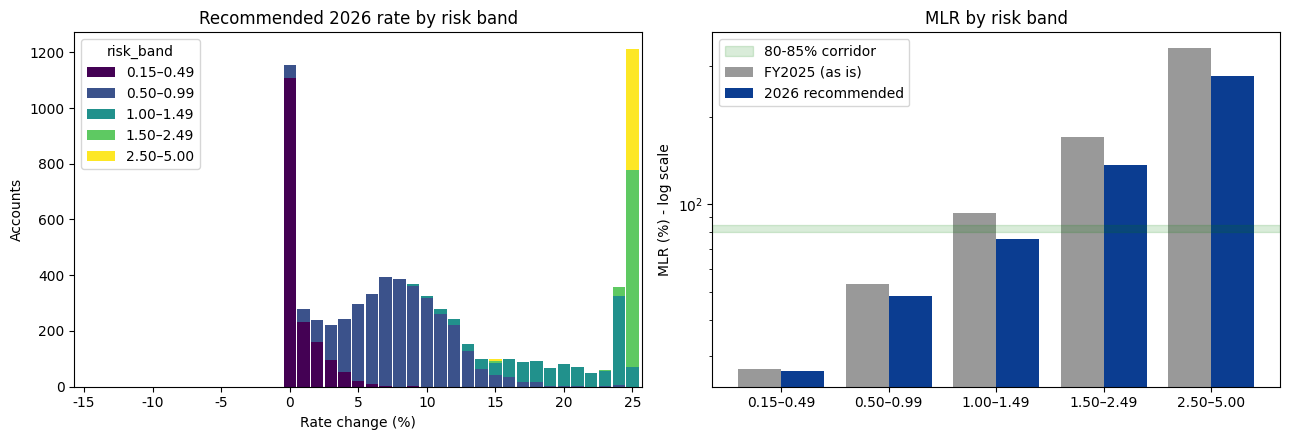

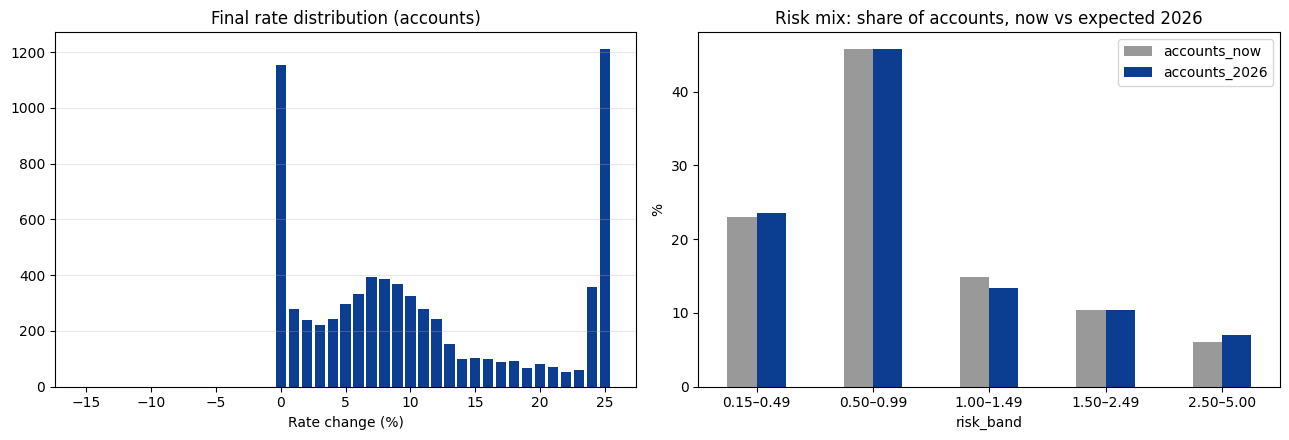

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rate_dist.plot(kind='bar', stacked=True, ax=axes[0], width=.9, colormap='viridis'); axes[0].set_title('Recommended 2026 rate by risk band'); axes[0].set_xlabel('Rate change (%)'); axes[0].set_ylabel('Accounts')
axes[0].set_xticks(range(0, len(rate_dist), 5), rate_dist.index[::5], rotation=0)
xb = np.arange(len(by_band)); axes[1].bar(xb - .2, 100 * by_band['fy2025_mlr'], .4, label='FY2025 (as is)', color='#999'); axes[1].bar(xb + .2, 100 * by_band['mlr_2026'], .4, label='2026 recommended', color='#0b3d91')
axes[1].axhspan(80, 85, color='g', alpha=.15, label='80-85% corridor'); axes[1].set_xticks(xb, by_band.index); axes[1].set_yscale('log'); axes[1].set_ylabel('MLR (%) - log scale'); axes[1].legend(); axes[1].set_title('MLR by risk band')
fig.tight_layout(); fig.savefig(OUT / 'plots' / '02_rates_and_mlr_by_risk_band.png', dpi=170); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(rd.index, rd['accounts'], color='#0b3d91'); ax[0].set_title('Final rate distribution (accounts)'); ax[0].set_xlabel('Rate change (%)'); ax[0].grid(axis='y', alpha=.3)
mix[['accounts_now', 'accounts_2026']].mul(100).plot(kind='bar', ax=ax[1], color=['#999', '#0b3d91']); ax[1].set_title('Risk mix: share of accounts, now vs expected 2026'); ax[1].set_ylabel('%'); ax[1].tick_params(axis='x', rotation=0)
fig.tight_layout(); fig.savefig(OUT / 'plots' / '03_rate_distribution_and_risk_mix.png', dpi=170); plt.show()

## 7 · All solutions compared on the v2 renewal curve
v1 recommendations re-scored on the v2 renewal curve
Same economics, same corrected curve, so the comparison isolates the decision itself.

,solution,expected_contribution,account_retention,premium_weighted_retention,case_mlr,accounts_at_cap,accounts_with_cut
0,v2 nominal MILP,2.636389e+09,0.8071,0.8100,0.8087,1825,0
1,v2 robust MILP,2.612325e+09,0.8375,0.8292,0.8126,1504,0
2,v2 FINAL robust + guardrails,2.585942e+09,0.8375,0.8304,0.8145,1211,0
3,v1 notebook 06 (heuristic),2.607244e+09,0.7989,0.7974,0.8087,2041,508
4,v1 notebook 07 (refined heuristic),2.377788e+09,0.8013,0.8045,0.8258,56,360


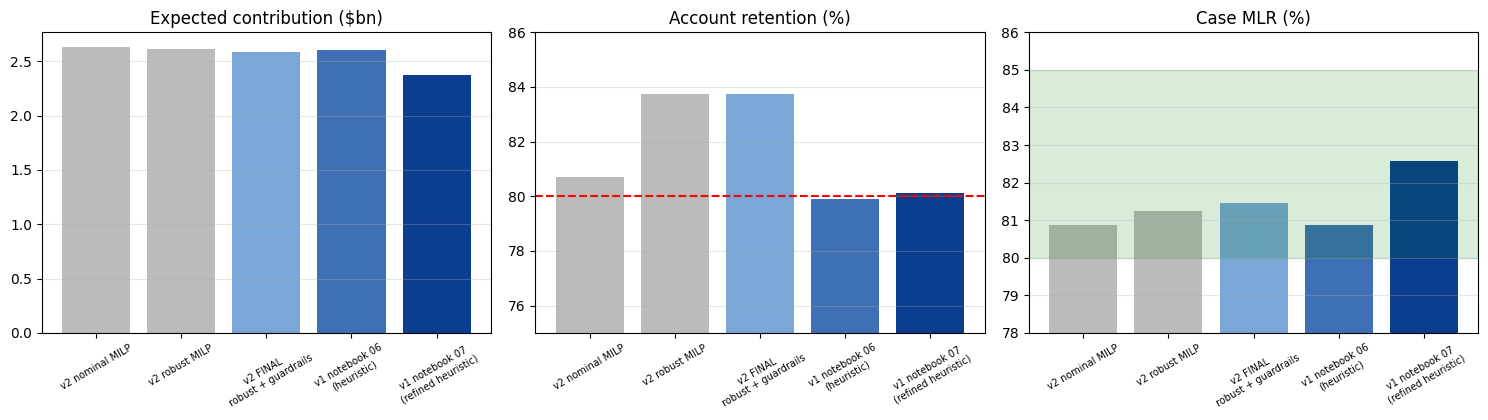

In [10]:
comp = [{'solution': 'v2 nominal MILP', **nom}, {'solution': 'v2 robust MILP', **rob}, {'solution': 'v2 FINAL robust + guardrails', **fin}]
for name, path in [('v1 notebook 06 (heuristic)', ROOT / 'outputs' / 'New_optimisation' / 'final_rate_recommendations.csv'),
                   ('v1 notebook 07 (refined heuristic)', ROOT / 'outputs' / 'refined optimisation' / 'refined_rate_recommendations.csv')]:
    if path.exists():
        v1 = pd.read_csv(path).set_index('account_id').reindex(snap['account_id'])
        ch = np.searchsorted(RATES, v1['selected_rate_change_pct'].to_numpy().astype(int))
        comp.append({'solution': name, **portfolio_metrics(ch, P, prem0, claims0)})
comp = pd.DataFrame(comp); comp.to_csv(OUT / 'solution_comparison_on_v2_curve.csv', index=False)
display(comp[['solution', 'expected_contribution', 'account_retention', 'premium_weighted_retention', 'case_mlr', 'accounts_at_cap', 'accounts_with_cut']].round(4))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3)); lab = [s.replace(' (', '\n(').replace('v2 FINAL', 'v2 FINAL\n') for s in comp['solution']]
cols = ['#bbb', '#bbb', '#7aa6d8', '#3f6fb5', '#0b3d91'][-len(comp):] if len(comp) == 5 else None
order = comp.index
ax[0].bar(lab, comp['expected_contribution'] / 1e9, color=cols); ax[0].set_title('Expected contribution ($bn)')
ax[1].bar(lab, 100 * comp['account_retention'], color=cols); ax[1].axhline(80, color='r', ls='--'); ax[1].set_ylim(75, 86); ax[1].set_title('Account retention (%)')
ax[2].bar(lab, 100 * comp['case_mlr'], color=cols); ax[2].axhspan(80, 85, color='g', alpha=.15); ax[2].set_ylim(78, 86); ax[2].set_title('Case MLR (%)')
for a in ax: a.tick_params(axis='x', labelsize=7, rotation=30); a.grid(axis='y', alpha=.3)
fig.tight_layout(); fig.savefig(OUT / 'plots' / '04_solution_comparison.png', dpi=170); plt.show()
np.save(OUT / 'choice_nominal.npy', choice_nom); np.save(OUT / 'choice_robust.npy', choice_rob); np.save(OUT / 'choice_final.npy', choice_fin)
pd.concat([solver, pd.DataFrame([{'run': 'robust MILP', **{k: v for k, v in rob_info.items() if k != 'constraint_names'}}]), pd.DataFrame([{'run': n, **{k: v for k, v in inf.items() if k != 'constraint_names'}} for n, (c, inf) in runs.items()])]).to_csv(OUT / 'solver_diagnostics.csv', index=False)